In [1]:
#Librerias

import numpy as np
import pandas as pd
import polars as ps
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

from scipy.sparse import csr_matrix
from collections import Counter


In [24]:
# Cargar el archivo raw
raw = ps.read_csv('~/Desktop/Practicas_Profesionales/Data_Raw/matrix.csv')

## EDA

In [34]:
# Conocer el tipo de dato de las columnas
raw.schema

Schema([('sample_name', String),
        ('DDX11L1', Int64),
        ('WASH7P', Int64),
        ('MIR6859-1', Int64),
        ('MIR1302-2', Int64),
        ('FAM138A', Int64),
        ('LOC105379212', Int64),
        ('OR4G4P', Int64),
        ('OR4G11P', Int64),
        ('OR4F5', Int64),
        ('LOC105379213', Int64),
        ('CICP27', Int64),
        ('LOC729737', Int64),
        ('LOC100996442', Int64),
        ('LOC105379214', Int64),
        ('LOC102725121', Int64),
        ('LOC102723897', Int64),
        ('MIR6859-2', Int64),
        ('RPL23AP21', Int64),
        ('LOC102723917', Int64),
        ('LOC105379431', Int64),
        ('RPL23AP24', Int64),
        ('LOC105379248', Int64),
        ('OR4F29', Int64),
        ('CICP7', Int64),
        ('LOC100132287', Int64),
        ('LOC100134822', Int64),
        ('LOC105378947', Int64),
        ('LOC101928626', Int64),
        ('MTND1P23', Int64),
        ('MTND2P28', Int64),
        ('MIR6723', Int64),
        ('OR4F16', Int64),
 

In [ ]:
# Contar cuantas columnas con cada tipo de dato hay

type_counts = Counter(raw.schema.values())
print(type_counts)

In [26]:
# Visualizar los datos crudos
raw.head(10)

sample_name,DDX11L1,WASH7P,MIR6859-1,MIR1302-2,FAM138A,LOC105379212,OR4G4P,OR4G11P,OR4F5,LOC105379213,CICP27,LOC729737,LOC100996442,LOC105379214,LOC102725121,LOC102723897,MIR6859-2,RPL23AP21,LOC102723917,LOC105379431,RPL23AP24,LOC105379248,OR4F29,CICP7,LOC100132287,LOC100134822,LOC105378947,LOC101928626,MTND1P23,MTND2P28,MIR6723,OR4F16,LOC105378582,CICP3,LOC100133331,LOC100288069,…,TRNF,RNR1,TRNV,RNR2,TRNL1,ND1,TRNI,TRNQ,TRNM,ND2,TRNW,TRNA,TRNN,TRNC,TRNY,COX1,TRNS1,TRND,COX2,TRNK,ATP8,ATP6,COX3,TRNG,ND3,TRNR,ND4L,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""AAACCCAAGGATTTCC-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,7,0,36,0,3,0,0,0,3,0,0,0,0,0,33,0,0,21,0,0,7,21,0,0,0,0,8,0,0,0,2,0,0,19,0,0
"""AAACCCAAGTATGGCG-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,2,0,7,0,2,0,0,0,1,0,0,0,0,0,5,0,0,5,0,0,3,5,0,0,0,0,5,0,0,0,0,0,0,3,0,0
"""AAACCCACAAAGTGTA-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,4,0,29,0,6,0,0,0,1,0,0,0,0,0,23,0,0,16,0,0,6,12,0,1,0,0,8,0,0,0,1,0,0,5,0,0
"""AAACCCACACTACTTT-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,11,0,98,0,2,0,0,0,3,0,0,0,0,0,19,0,0,17,0,0,7,19,0,6,0,2,6,0,0,0,6,0,0,8,0,0
"""AAACCCACAGTGAGCA-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
"""AAACCCAGTCACCCTT-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,0,19,0,5,0,0,0,2,0,0,0,0,0,29,0,0,20,0,0,5,23,0,3,0,0,19,0,0,0,2,0,0,7,0,0
"""AAACCCAGTGTCCACG-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,3,0,21,0,5,0,0,0,0,0,0,0,0,0,32,0,0,29,0,0,18,23,0,1,0,1,16,0,0,0,7,0,0,20,0,0
"""AAACCCATCATAAGGA-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,8,0,63,0,15,0,0,0,7,0,0,0,0,0,115,0,0,74,0,0,24,70,0,6,0,1,44,0,0,0,4,0,0,54,0,0
"""AAACCCATCTGTCCCA-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,2,0,11,0,0,0,0,0,2,0,0,0,0,0,22,0,0,13,0,0,3,11,0,1,0,0,6,0,0,0,3,0,0,6,0,0


In [ ]:
raw.describe()

Cuenta de valores nulos en los datos.

In [33]:
raw.null_count

raw.null_count().sum()

<bound method DataFrame.null_count of shape: (76_533, 50_282)
┌─────────────────────────────────┬─────────┬────────┬───────────┬───┬──────┬──────┬──────┬──────┐
│ sample_name                     ┆ DDX11L1 ┆ WASH7P ┆ MIR6859-1 ┆ … ┆ TRNE ┆ CYTB ┆ TRNT ┆ TRNP │
│ ---                             ┆ ---     ┆ ---    ┆ ---       ┆   ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ str                             ┆ i64     ┆ i64    ┆ i64       ┆   ┆ i64  ┆ i64  ┆ i64  ┆ i64  │
╞═════════════════════════════════╪═════════╪════════╪═══════════╪═══╪══════╪══════╪══════╪══════╡
│ AAACCCAAGGATTTCC-LKTX_190129_0… ┆ 0       ┆ 0      ┆ 0         ┆ … ┆ 0    ┆ 19   ┆ 0    ┆ 0    │
│ AAACCCAAGTATGGCG-LKTX_190129_0… ┆ 0       ┆ 0      ┆ 0         ┆ … ┆ 0    ┆ 3    ┆ 0    ┆ 0    │
│ AAACCCACAAAGTGTA-LKTX_190129_0… ┆ 0       ┆ 0      ┆ 0         ┆ … ┆ 0    ┆ 5    ┆ 0    ┆ 0    │
│ AAACCCACACTACTTT-LKTX_190129_0… ┆ 0       ┆ 0      ┆ 0         ┆ … ┆ 0    ┆ 8    ┆ 0    ┆ 0    │
│ AAACCCACAGTGAGCA-LKTX_190129_0… ┆ 0       ┆ 0

In [ ]:
# Contar cuantas columnas hay con nulls
raw.null_count().transpose().filter(ps.col("column_0") > 0).shape

Se calcula el porcentaje de ceros por columna

In [5]:

porcentaje_ceros = raw.select(
    (
        ps.all()
        .exclude("sample_name")   # excluye la columna string
        .eq(0)
        .sum()
        / ps.len()
        * 100
    )
)

type(porcentaje_ceros)
print(porcentaje_ceros)

shape: (1, 50_281)
┌─────────┬──────────┬───────────┬───────────┬───┬───────┬───────────┬───────────┬───────────┐
│ DDX11L1 ┆ WASH7P   ┆ MIR6859-1 ┆ MIR1302-2 ┆ … ┆ TRNE  ┆ CYTB      ┆ TRNT      ┆ TRNP      │
│ ---     ┆ ---      ┆ ---       ┆ ---       ┆   ┆ ---   ┆ ---       ┆ ---       ┆ ---       │
│ f64     ┆ f64      ┆ f64       ┆ f64       ┆   ┆ f64   ┆ f64       ┆ f64       ┆ f64       │
╞═════════╪══════════╪═══════════╪═══════════╪═══╪═══════╪═══════════╪═══════════╪═══════════╡
│ 100.0   ┆ 98.07926 ┆ 100.0     ┆ 100.0     ┆ … ┆ 100.0 ┆ 14.813218 ┆ 99.998693 ┆ 99.994773 │
└─────────┴──────────┴───────────┴───────────┴───┴───────┴───────────┴───────────┴───────────┘


Histograma del porcentaje de ceros por columna

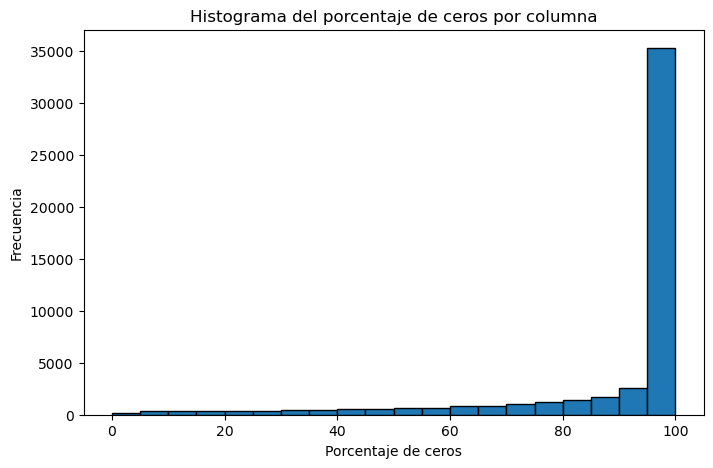

In [6]:

# Extraemos los valores como lista
valores = porcentaje_ceros.row(0)

plt.figure(figsize=(8,5))
plt.hist(valores, bins=20, edgecolor="black")
plt.xlabel("Porcentaje de ceros")
plt.ylabel("Frecuencia")
plt.title("Histograma del porcentaje de ceros por columna")
plt.show()

Identificar las columnas con solo ceros

In [9]:

columnas_100_ceros = [
    col
    for col in raw.columns[1:]  # excluye sample_name
    if raw.select((ps.col(col) == 0).sum() == raw.height).item()
]

#print(columnas_100_ceros)

(0, 1)

Counter({Int64: 50281, String: 1})


In [30]:
raw.drop('sample_name')

DDX11L1,WASH7P,MIR6859-1,MIR1302-2,FAM138A,LOC105379212,OR4G4P,OR4G11P,OR4F5,LOC105379213,CICP27,LOC729737,LOC100996442,LOC105379214,LOC102725121,LOC102723897,MIR6859-2,RPL23AP21,LOC102723917,LOC105379431,RPL23AP24,LOC105379248,OR4F29,CICP7,LOC100132287,LOC100134822,LOC105378947,LOC101928626,MTND1P23,MTND2P28,MIR6723,OR4F16,LOC105378582,CICP3,LOC100133331,LOC100288069,LOC105378581,…,TRNF,RNR1,TRNV,RNR2,TRNL1,ND1,TRNI,TRNQ,TRNM,ND2,TRNW,TRNA,TRNN,TRNC,TRNY,COX1,TRNS1,TRND,COX2,TRNK,ATP8,ATP6,COX3,TRNG,ND3,TRNR,ND4L,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,7,0,36,0,3,0,0,0,3,0,0,0,0,0,33,0,0,21,0,0,7,21,0,0,0,0,8,0,0,0,2,0,0,19,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,2,0,7,0,2,0,0,0,1,0,0,0,0,0,5,0,0,5,0,0,3,5,0,0,0,0,5,0,0,0,0,0,0,3,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,4,0,29,0,6,0,0,0,1,0,0,0,0,0,23,0,0,16,0,0,6,12,0,1,0,0,8,0,0,0,1,0,0,5,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,11,0,98,0,2,0,0,0,3,0,0,0,0,0,19,0,0,17,0,0,7,19,0,6,0,2,6,0,0,0,6,0,0,8,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,18,0,6,0,0,0,4,0,0,0,0,0,26,0,0,17,0,0,10,24,0,9,0,1,8,0,0,0,3,0,0,9,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0


## Dataframe quitando columnas que son 100% Ceros
Crear una version del dataframe eliminando las columnas que son unicamente ceros


In [10]:
# columnas_100_ceros

df_noZeros = raw.drop(columnas_100_ceros)
df_noZeros.head(5)


sample_name,WASH7P,LOC105379213,LOC729737,LOC100996442,LOC105379214,LOC102725121,LOC102723897,LOC102723917,LOC105379431,LOC105379248,LOC100134822,LOC105378947,LOC101928626,MIR6723,LOC105378582,LOC100288069,LOC105378581,LOC100287934,LOC105378580,FAM87B,LINC00115,LINC01128,FAM41C,LOC284600,LOC100130417,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,LOC105378583,HES4,ISG15,AGRN,LOC100288175,LOC105369174,…,LOC102723951,LOC100996911,DAZ3,DAZ4,LOC101929235,LOC102724004,LOC105377243,LOC105377244,TRNF,RNR1,TRNV,RNR2,TRNL1,ND1,TRNI,TRNQ,TRNM,ND2,TRNN,TRNC,COX1,TRND,COX2,TRNK,ATP8,ATP6,COX3,TRNG,ND3,ND4L,ND4,TRNH,ND5,ND6,CYTB,TRNT,TRNP
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""AAACCCAAGGATTTCC-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,7,0,36,0,3,0,0,0,3,0,0,33,0,21,0,0,7,21,0,0,0,8,0,2,0,19,0,0
"""AAACCCAAGTATGGCG-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,2,0,7,0,2,0,0,0,1,0,0,5,0,5,0,0,3,5,0,0,0,5,0,0,0,3,0,0
"""AAACCCACAAAGTGTA-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,…,0,0,0,0,0,0,0,0,0,4,0,29,0,6,0,0,0,1,0,0,23,0,16,0,0,6,12,0,1,0,8,0,1,0,5,0,0
"""AAACCCACACTACTTT-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,11,0,98,0,2,0,0,0,3,0,0,19,0,17,0,0,7,19,0,6,2,6,0,6,0,8,0,0
"""AAACCCACAGTGAGCA-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""AAACGCTCAAGATTGA-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,4,0,22,0,1,0,0,0,0,0,0,28,0,18,0,0,7,16,0,0,0,9,0,0,0,11,0,0
"""AAACGCTCACAGTCAT-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,12,0,6,0,0,0,0,0,0,26,0,3,0,0,3,17,0,0,0,11,0,0,0,11,0,0
"""AAACGCTCAGCTGTGC-LKTX_190129_0…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,…,0,0,0,0,0,0,0,0,0,3,0,21,0,6,0,0,0,3,0,0,11,0,12,0,0,5,10,0,1,0,9,0,1,0,9,0,0


Visualizamos que ya no hay columnas con 100% ceros


In [11]:

porcentaje_ceros = df_noZeros.select(
    (
        ps.all()
        .exclude("sample_name")
        .eq(0)
        .sum()
        / ps.len()
        * 100
    )
)

print(porcentaje_ceros)

shape: (1, 33_686)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ WASH7P   ┆ LOC105379 ┆ LOC729737 ┆ LOC100996 ┆ … ┆ ND6       ┆ CYTB      ┆ TRNT      ┆ TRNP      │
│ ---      ┆ 213       ┆ ---       ┆ 442       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64      ┆ ---       ┆ f64       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│          ┆ f64       ┆           ┆ f64       ┆   ┆           ┆           ┆           ┆           │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 98.07926 ┆ 99.742595 ┆ 97.743457 ┆ 99.793553 ┆ … ┆ 97.452079 ┆ 14.813218 ┆ 99.998693 ┆ 99.994773 │
└──────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


Histograma del porcentaje de ceros por columna, eliminando las columnas 100% ceros

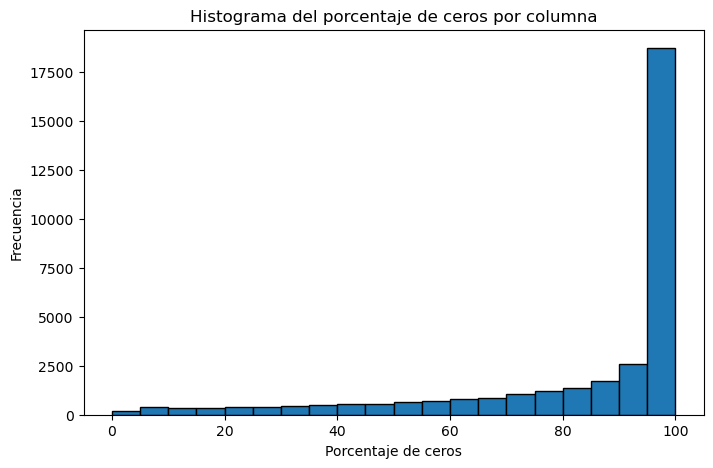

In [11]:

valores = porcentaje_ceros.row(0)

plt.figure(figsize=(8,5))
plt.hist(valores, bins=20, edgecolor="black")
plt.xlabel("Porcentaje de ceros")
plt.ylabel("Frecuencia")
plt.title("Histograma del porcentaje de ceros por columna")
plt.show()

   Verificar si existen celulas que no expresen ningun gen. Esto lo estoy haciendo sobre el andata

In [68]:
# suma por célula (filas)
cell_sums = np.array(adata.X.sum(axis=1)).flatten()

# encontrar células con suma 0
zero_cells = cell_sums == 0

# cuántas hay
print(f"Células con 0 expresión: {zero_cells.sum()}")

# ver cuáles son (IDs)
print(adata.obs_names[zero_cells])

Células con 0 expresión: 0
Index([], dtype='object', name='sample_name')


## Crear el objeto Ann Data
Para crear el objeto AnnData es necesario tener un dataframe no vacío dondelos indices sean los nombres de las filas para Obs, los nombres de las columnas para Var y una matriz exclusivamente numerica para X.

In [57]:
sample_name = df_noZeros['sample_name']
print(sample_name)

# df_noZeros.drop('sample_name')

shape: (76_533,)
Series: 'sample_name' [str]
[
	"AAACCCAAGGATTTCC-LKTX_190129_0…
	"AAACCCAAGTATGGCG-LKTX_190129_0…
	"AAACCCACAAAGTGTA-LKTX_190129_0…
	"AAACCCACACTACTTT-LKTX_190129_0…
	"AAACCCACAGTGAGCA-LKTX_190129_0…
	…
	"TTTGTTGAGATGGCGT-LKTX_190130_0…
	"TTTGTTGCACAGCCAC-LKTX_190130_0…
	"TTTGTTGCAGAGACTG-LKTX_190130_0…
	"TTTGTTGCATAATGAG-LKTX_190130_0…
	"TTTGTTGTCTACTCAT-LKTX_190130_0…
]


In [12]:
# Crear matriz sparse

X_sparse = csr_matrix(df_noZeros.drop("sample_name").to_numpy())
X_sparse.shape

(76533, 33686)

In [13]:
# Crer dataframes para Var y Obs. Usamos como variables dummy, para Obs el min y max de expresion de cualquier gen en esa muestra y para Var el porcentaje de ceros de la columna.

# Columnas de genes (excluyendo sample_name)
columnas_genes = [c for c in df_noZeros.columns if c != "sample_name"]

# Crear obs como DataFrame de pandas (AnnData lo necesita)
obs = df_noZeros.select([
    ps.col("sample_name"),
    ps.min_horizontal(columnas_genes).alias("Min"),
    ps.max_horizontal(columnas_genes).alias("Max")
]).to_pandas().set_index("sample_name")

# 'porcentaje_ceros' ya era un dataframe de polars que tenia como indices las columnas y como entrada el porcentaje de ceros, solo lo convertimos a pandas

porcentaje_ceros = (
    porcentaje_ceros
    .to_pandas()
    .T
    .rename(columns={'0': '%0'})
)

var = porcentaje_ceros

In [64]:

adata = ad.AnnData(
    X=X_sparse,
    obs=obs,
    var=var
)

In [65]:
adata.obs

,Min,Max,cluster_label,class_label,subclass_label
sample_name,,,,,
AAACCCAAGGATTTCC-LKTX_190129_01_A01,0,570,Inh L1-2 SST CCNJL,GABAergic,Sst
AAACCCAAGTATGGCG-LKTX_190129_01_A01,0,855,Exc L5-6 FEZF2 IFNG-AS1,Glutamatergic,L5/6 NP
AAACCCACAAAGTGTA-LKTX_190129_01_A01,0,940,Exc L3-5 RORB LINC01202,Glutamatergic,L5 IT
AAACCCACACTACTTT-LKTX_190129_01_A01,0,98,Exc L2 LINC00507 GLRA3,Glutamatergic,L2/3 IT
AAACCCACAGTGAGCA-LKTX_190129_01_A01,0,198,Oligo L2-6 OPALIN FTH1P3,Non-Neuronal,Oligo
...,...,...,...,...,...
TTTGTTGAGATGGCGT-LKTX_190130_01_H01,0,51,Oligo L2-6 OPALIN FTH1P3,Non-Neuronal,Oligo
TTTGTTGCACAGCCAC-LKTX_190130_01_H01,0,1100,Exc L3-5 RORB LNX2,Glutamatergic,L5 IT
TTTGTTGCAGAGACTG-LKTX_190130_01_H01,0,65,Exc L2-3 RORB PTPN3,Glutamatergic,L2/3 IT


## Metadata

In [18]:
metadata = pd.read_csv('~/Desktop/Practicas_Profesionales/Data_Raw/metadata.csv')

In [33]:
metadata

,sample_name,exp_component_name,cluster_label,cluster_color,cluster_order,class_label,class_color,class_order,subclass_label,subclass_color,...,cell_type_designation_label,cell_type_designation_color,cell_type_designation_order,external_donor_name_label,external_donor_name_color,external_donor_name_order,specimen_type,full_genotype_label,outlier_call,outlier_type
0,AAACCCAAGGATTTCC-LKTX_190129_01_A01,AAACCCAAGGATTTCC-21L8TX_180927_001_A01,Inh L1-2 SST CCNJL,#fb8d00,50,GABAergic,#FF7373,1,Sst,#FF9900,...,Neuron 50,#fb8d00,50,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
1,AAACCCAAGTATGGCG-LKTX_190129_01_A01,AAACCCAAGTATGGCG-21L8TX_180927_001_A01,Exc L5-6 FEZF2 IFNG-AS1,#2c815f,116,Glutamatergic,#3DCC3D,2,L5/6 NP,#3E9E64,...,Neuron 116,#2c815f,116,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
2,AAACCCACAAAGTGTA-LKTX_190129_01_A01,AAACCCACAAAGTGTA-21L8TX_180927_001_A01,Exc L3-5 RORB LINC01202,#547d7a,87,Glutamatergic,#3DCC3D,2,L5 IT,#50B2AD,...,Neuron 87,#547d7a,87,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
3,AAACCCACACTACTTT-LKTX_190129_01_A01,AAACCCACACTACTTT-21L8TX_180927_001_A01,Exc L2 LINC00507 GLRA3,#cecd32,75,Glutamatergic,#3DCC3D,2,L2/3 IT,#C4EC04,...,Neuron 75,#cecd32,75,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
4,AAACCCACAGTGAGCA-LKTX_190129_01_A01,AAACCCACAGTGAGCA-21L8TX_180927_001_A01,Oligo L2-6 OPALIN FTH1P3,#003a28,120,Non-Neuronal,#171799,3,Oligo,#2E3E39,...,Non-neuron 3,#003a28,120,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76528,TTTGTTGAGATGGCGT-LKTX_190130_01_H01,TTTGTTGAGATGGCGT-35L8TX_181108_001_D01,Oligo L2-6 OPALIN FTH1P3,#003a28,120,Non-Neuronal,#171799,3,Oligo,#2E3E39,...,Non-neuron 3,#003a28,120,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
76529,TTTGTTGCACAGCCAC-LKTX_190130_01_H01,TTTGTTGCACAGCCAC-35L8TX_181108_001_D01,Exc L3-5 RORB LNX2,#01d9d5,90,Glutamatergic,#3DCC3D,2,L5 IT,#50B2AD,...,Neuron 90,#01d9d5,90,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
76530,TTTGTTGCAGAGACTG-LKTX_190130_01_H01,TTTGTTGCAGAGACTG-35L8TX_181108_001_D01,Exc L2-3 RORB PTPN3,#b7ce00,81,Glutamatergic,#3DCC3D,2,L2/3 IT,#C4EC04,...,Neuron 81,#b7ce00,81,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN
76531,TTTGTTGCATAATGAG-LKTX_190130_01_H01,TTTGTTGCATAATGAG-35L8TX_181108_001_D01,Oligo L2-6 OPALIN FTH1P3,#003a28,120,Non-Neuronal,#171799,3,Oligo,#2E3E39,...,Non-neuron 3,#003a28,120,H18.30.001,#FF7373,1,nucleus,NaN,False,NaN


In [29]:
df_noZeros.shape

(76533, 33687)

In [62]:
# Definir el/los posibles targets

cluster_label = metadata['cluster_label']
class_label = metadata['class_label']
subclass_label = metadata['subclass_label']

# Hacer que coincidan los indices
cluster_label.index = obs.index
class_label.index = obs.index
subclass_label.index = obs.index

# Agregarlos al anndata

obs['cluster_label'] = cluster_label
obs['class_label'] = class_label
obs['subclass_label'] = subclass_label


In [63]:
obs

,Min,Max,cluster_label,class_label,subclass_label
sample_name,,,,,
AAACCCAAGGATTTCC-LKTX_190129_01_A01,0,570,Inh L1-2 SST CCNJL,GABAergic,Sst
AAACCCAAGTATGGCG-LKTX_190129_01_A01,0,855,Exc L5-6 FEZF2 IFNG-AS1,Glutamatergic,L5/6 NP
AAACCCACAAAGTGTA-LKTX_190129_01_A01,0,940,Exc L3-5 RORB LINC01202,Glutamatergic,L5 IT
AAACCCACACTACTTT-LKTX_190129_01_A01,0,98,Exc L2 LINC00507 GLRA3,Glutamatergic,L2/3 IT
AAACCCACAGTGAGCA-LKTX_190129_01_A01,0,198,Oligo L2-6 OPALIN FTH1P3,Non-Neuronal,Oligo
...,...,...,...,...,...
TTTGTTGAGATGGCGT-LKTX_190130_01_H01,0,51,Oligo L2-6 OPALIN FTH1P3,Non-Neuronal,Oligo
TTTGTTGCACAGCCAC-LKTX_190130_01_H01,0,1100,Exc L3-5 RORB LNX2,Glutamatergic,L5 IT
TTTGTTGCAGAGACTG-LKTX_190130_01_H01,0,65,Exc L2-3 RORB PTPN3,Glutamatergic,L2/3 IT


## Formato H5
Aqui ya se obtuvo el objeto de AnnData y se convirtio a formto H5 

In [23]:
var.columns = var.columns.astype(str)

In [72]:
adata.var

,%de0
WASH7P,98.079260
LOC105379213,99.742595
LOC729737,97.743457
LOC100996442,99.793553
LOC105379214,99.998693
...,...
ND5,53.508944
ND6,97.452079
CYTB,14.813218
TRNT,99.998693


In [71]:
print(adata.var.columns)
adata.var.rename(columns={"0": "%de0"}, inplace=True)
print(adata.var.columns)

Index(['0'], dtype='object')
Index(['%de0'], dtype='object')


In [13]:
adata.write("humanM1.h5ad")

In [ ]:
ta_cargado = ad.read_h5ad("mi_adata.h5ad")

### Cargo y confirmo que funcione el archivo h5ad

In [2]:

# Cargar el archivo
adata = sc.read_h5ad("humanM1.h5ad")

# Imprimir resumen general
print(adata)

# Información más detallada
print("\n--- OBS (células) ---")
print(adata.obs.head())
print(adata.obs.columns)

print("\n--- VAR (genes) ---")
print(adata.var.head())
print(adata.var.columns)

print("\n--- Dimensiones ---")
print(f"Células: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")

print("\n--- Matriz X ---")
print(type(adata.X))

AnnData object with n_obs × n_vars = 76533 × 33686
    obs: 'Min', 'Max', 'cluster_label', 'class_label', 'subclass_label'
    var: '%de0'

--- OBS (células) ---
                                     Min  Max             cluster_label  \
sample_name                                                               
AAACCCAAGGATTTCC-LKTX_190129_01_A01    0  570        Inh L1-2 SST CCNJL   
AAACCCAAGTATGGCG-LKTX_190129_01_A01    0  855   Exc L5-6 FEZF2 IFNG-AS1   
AAACCCACAAAGTGTA-LKTX_190129_01_A01    0  940   Exc L3-5 RORB LINC01202   
AAACCCACACTACTTT-LKTX_190129_01_A01    0   98    Exc L2 LINC00507 GLRA3   
AAACCCACAGTGAGCA-LKTX_190129_01_A01    0  198  Oligo L2-6 OPALIN FTH1P3   

                                       class_label subclass_label  
sample_name                                                        
AAACCCAAGGATTTCC-LKTX_190129_01_A01      GABAergic            Sst  
AAACCCAAGTATGGCG-LKTX_190129_01_A01  Glutamatergic        L5/6 NP  
AAACCCACAAAGTGTA-LKTX_190129_01_A01  Glu

## Calculo vecinos, despues UMAP y TSNE

In [12]:
adata.obsm

AxisArrays with keys: X_pca, X_umap, X_tsne

In [8]:
adata.X = adata.X.astype('float32')

In [9]:

# Asegúrate de tener vecinos calculados (necesario para UMAP y t-SNE)
sc.pp.pca(adata, n_comps=50)        # PCA previo
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)

# Calcular UMAP
sc.tl.umap(adata)

# Calcular t-SNE
sc.tl.tsne(adata, n_pcs=50)


/home/macosta/.conda/envs/PPIII/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Analizar balance de clases, Prueba de Concepto, subsampleo

In [16]:
# Cuenta de ocurrencias por clase

for col in ['cluster_label', 'class_label', 'subclass_label']:
    print(f"\n=== {col} ===")
    print(adata.obs[col].value_counts(normalize=False)))



=== cluster_label ===
cluster_label
Exc L2 LINC00507 GLRA3       12485
Exc L3-5 RORB LNX2            4631
Exc L3 LAMP5 CARM1P1          4044
Exc L2-3 RORB CCDC68          3331
Inh L2-5 PVALB RPH3AL         3253
                             ...  
VLMC L1-5 PDGFRA COLEC12        40
Inh L1 SST P4HA3                38
Inh L5-6 SST DNAJC14            35
Exc L6 FEZF2 PDYN               22
Oligo L5-6 OPALIN LDLRAP1        6
Name: count, Length: 127, dtype: int64

=== class_label ===
class_label
Glutamatergic    48536
GABAergic        23992
Non-Neuronal      4005
Name: count, dtype: int64

=== subclass_label ===
subclass_label
L2/3 IT       24231
L5 IT         13834
Pvalb          7782
Sst            5936
Vip            4858
Lamp5          4454
L6 CT          3734
Oligo          2942
L6b            2236
L6 IT          1829
L5/6 NP        1487
Sncg            895
L5 ET           858
Astro           568
L6 IT Car3      327
OPC             283
Micro-PVM       108
Sst Chodl        67
Endo        

In [22]:
# Submuestreo balanceado

n_per_class = 4000  # células por clase

idx = []
for cls, df in adata.obs.groupby('class_label'):
    if len(df) >= n_per_class:
        idx.extend(np.random.choice(df.index, n_per_class, replace=False))
    else:
        idx.extend(df.index)  # si hay pocas, toma todas

adata_balanced = adata[idx].copy()

/tmp/ipykernel_1087135/3717059396.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cls, df in adata.obs.groupby('class_label'):


In [23]:
adata_balanced.obs['class_label'].value_counts()

class_label
GABAergic        4000
Glutamatergic    4000
Non-Neuronal     4000
Name: count, dtype: int64

In [ ]:
## 